In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from os import listdir
from os.path import isfile, join
import json
import seaborn as sns

# **UCLK-C**

In [101]:
# Experiments Information
d = 8
D = 120
T = 10000
N = 200
delta = 0.05
epsilon = 1e-06

In [102]:
algo_list = ['UCLK_C']
colors = sns.color_palette('bright', n_colors=len(algo_list))

In [103]:
def json_parser(path):
    with open(path) as f:
        data = json.load(f)
        return data['cumulative_regret'][-1]

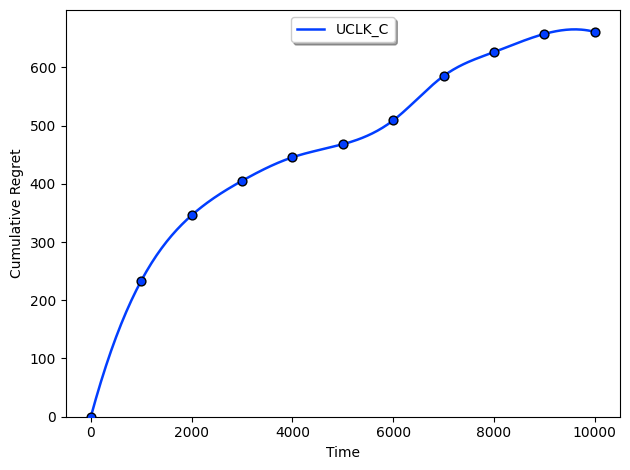

In [104]:
plt.figure()
for i in range(len(algo_list)):
    regret = [0]
    for t in range(1000, 11000, 1000):
        directory = f"./data/hardtolearn/{algo_list[i]}(discrete)/D={D}/regret_d_{d}_D_{D}.00_T_{t}_N_{N}_delta_{delta}_epsilon_{epsilon}/"
        file_list = [f for f in listdir(directory) if isfile(join(directory, f))]
        if '.DS_Store' in file_list:
            file_list.remove('.DS_Store')
        if '.ipynb_checkpoints' in file_list:
            file_list.remove('.ipynb_checkpoints')

        reg = 0
        for j in range(len(file_list)):
            reg += json_parser(directory + file_list[j])

        regret.append(reg / 10)

    timestep = np.arange(len(regret)) * 1000

    # Create a smooth spline fit
    spline = make_interp_spline(timestep, regret, k=3)  # k=3 for cubic spline
    smooth_timestep = np.linspace(timestep.min(), timestep.max(), 300)  # 300 points for smoothness
    smooth_regret = spline(smooth_timestep)

    plt.rc('font', size=10)        # Default font size
    plt.rc('axes', labelsize=10)   # x, y-axis label font size
    plt.rc('xtick', labelsize=10)  # x-axis tick font size
    plt.rc('ytick', labelsize=10)  # y-axis tick font size
    plt.rc('legend', fontsize=10)  # Legend font size

    # Plot the smoothed spline curve
    plt.plot(smooth_timestep, smooth_regret, color=colors[i], linewidth=1.8, label=algo_list[i])
    plt.scatter(timestep, regret, color=colors[i], s=40, edgecolors='k', zorder=5)  # Markers at original data points
    
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, loc='upper center', fancybox=True, shadow=True, ncol=3)
plt.xlabel("Time")
plt.ylabel("Cumulative Regret")
plt.ylim(0)
plt.tight_layout()
plt.savefig(f'(Hard-to-learn, UCLK-C)_regret_d_{d}_D_{D}_T_{T}_N_{N}_delta_{delta}_epsilon_{epsilon}.pdf', dpi=300)
plt.show()

# **UCRL2-VTR(Bernstein)**

In [105]:
# Experiments Information

d = 8
D = 120
T = 10000
N = 50
delta = 0.05
epsilon = 1e-06

In [106]:
algo_list = ['UCRL2_VTR(BERNSTEIN)']
colors = sns.color_palette('bright', n_colors=len(algo_list))

In [107]:
def json_parser(path):
    with open(path) as f:
        data = json.load(f)
        return data['cumulative_regret'][-1]

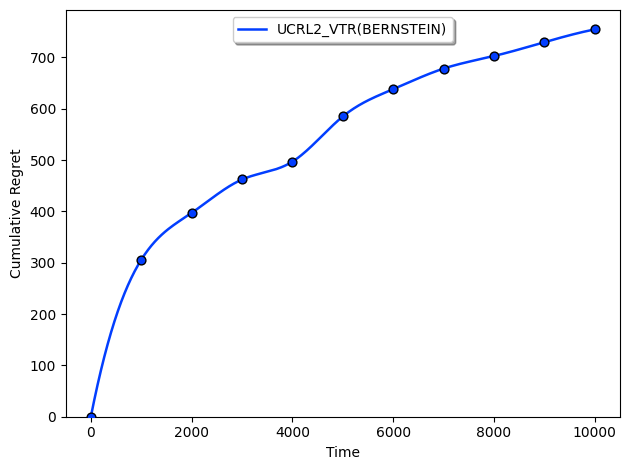

In [108]:
plt.figure()
for i in range(len(algo_list)):
    regret = [0]
    for t in range(1000, 11000, 1000):
        directory = f"./data/hardtolearn/{algo_list[i]}(discrete)/D={D}/regret_d_{d}_D_{D}.00_T_{t}_N_{N}_delta_{delta}_epsilon_{epsilon}/"
        file_list = [f for f in listdir(directory) if isfile(join(directory, f))]
        if '.DS_Store' in file_list:
            file_list.remove('.DS_Store')
        if '.ipynb_checkpoints' in file_list:
            file_list.remove('.ipynb_checkpoints')

        reg = 0
        for j in range(len(file_list)):
            reg += json_parser(directory + file_list[j])

        regret.append(reg / 10)

    timestep = np.arange(len(regret)) * 1000

    # Create a smooth spline fit
    spline = make_interp_spline(timestep, regret, k=3)  # k=3 for cubic spline
    smooth_timestep = np.linspace(timestep.min(), timestep.max(), 300)  # 300 points for smoothness
    smooth_regret = spline(smooth_timestep)

    plt.rc('font', size=10)        # Default font size
    plt.rc('axes', labelsize=10)   # x, y-axis label font size
    plt.rc('xtick', labelsize=10)  # x-axis tick font size
    plt.rc('ytick', labelsize=10)  # y-axis tick font size
    plt.rc('legend', fontsize=10)  # Legend font size

    # Plot the smoothed spline curve
    plt.plot(smooth_timestep, smooth_regret, color=colors[i], linewidth=1.8, label=algo_list[i])
    plt.scatter(timestep, regret, color=colors[i], s=40, edgecolors='k', zorder=5)  # Markers at original data points
    
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, loc='upper center', fancybox=True, shadow=True, ncol=3)
plt.xlabel("Time")
plt.ylabel("Cumulative Regret")
plt.ylim(0)
plt.tight_layout()
plt.savefig(f'(Hard-to-learn, UCRL2-VTR(Bernstein))_regret_d_{d}_D_{D}_T_{T}_N_{N}_delta_{delta}_epsilon_{epsilon}.pdf', dpi=300)
plt.show()

# **Combined Plot**

In [96]:
# Common Setting

d = 8
D = 120
T = 10000
delta = 0.05
epsilon = 1e-06

In [97]:
algo_list_with_N = [('UCLK_C', 200), ('UCRL2_VTR(BERNSTEIN)', 50)]
colors = sns.color_palette('bright', n_colors=len(algo_list_with_N))

In [98]:
def json_parser(path):
    with open(path) as f:
        data = json.load(f)
        return data['cumulative_regret'][-1]

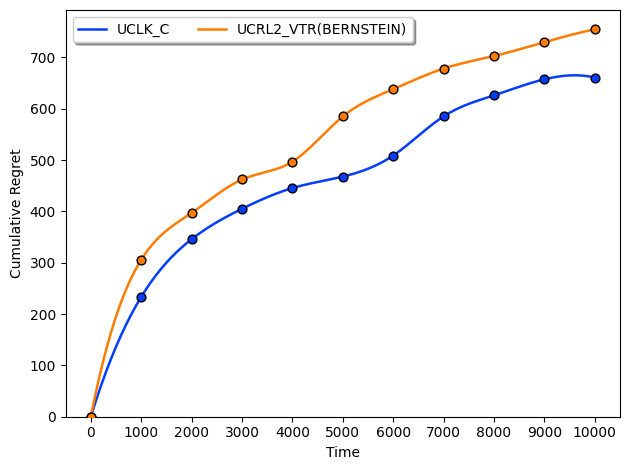

In [99]:
plt.figure()
for i in range(len(algo_list_with_N)):
    algo_name = algo_list_with_N[i][0]
    algo_N = algo_list_with_N[i][1]
    regret = [0]
    for t in range(1000, 11000, 1000):
        directory = f"./data/hardtolearn/{algo_name}(discrete)/D={D}/regret_d_{d}_D_{D}.00_T_{t}_N_{algo_N}_delta_{delta}_epsilon_{epsilon}/"
        file_list = [f for f in listdir(directory) if isfile(join(directory, f))]
        if '.DS_Store' in file_list:
            file_list.remove('.DS_Store')
        if '.ipynb_checkpoints' in file_list:
            file_list.remove('.ipynb_checkpoints')

        reg = 0
        for j in range(len(file_list)):
            reg += json_parser(directory + file_list[j])

        regret.append(reg / 10)

    timestep = np.arange(len(regret)) * 1000

    # Create a smooth spline fit
    spline = make_interp_spline(timestep, regret, k=3)  # k=3 for cubic spline
    smooth_timestep = np.linspace(timestep.min(), timestep.max(), 300)  # 300 points for smoothness
    smooth_regret = spline(smooth_timestep)

    plt.rc('font', size=10)        # Default font size
    plt.rc('axes', labelsize=10)   # x, y-axis label font size
    plt.rc('xtick', labelsize=10)  # x-axis tick font size
    plt.rc('ytick', labelsize=10)  # y-axis tick font size
    plt.rc('legend', fontsize=10)  # Legend font size

    # Plot the smoothed spline curve
    plt.plot(smooth_timestep, smooth_regret, color=colors[i], linewidth=1.8, label=algo_name)
    plt.scatter(timestep, regret, color=colors[i], s=40, edgecolors='k', zorder=5)  # Markers at original data points
    
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, loc='upper left', fancybox=True, shadow=True, ncol=3)
plt.xlabel("Time")
plt.ylabel("Cumulative Regret")
plt.xticks(range(0, 11000, 1000))
plt.ylim(0)
plt.tight_layout()
plt.savefig(f'(Hard-to-learn, UCLK-C, UCRL2-VTR(Bernstein))_regret_d_{d}_D_{D}_T_{T}_delta_{delta}_epsilon_{epsilon}.pdf', dpi=300)
plt.show()